# Clase 2: Regularización — L1, L2 y Elastic Net

Implementamos regularización desde cero usando el **dataset Diabetes** (scikit-learn).

- **Sin regularización**: baseline con overfitting
- **Ridge (L2)**: penaliza `Σwᵢ²` → pesos pequeños pero nunca 0
- **Lasso (L1)**: penaliza `Σ|wᵢ|` → elimina features (pesos = 0)
- **Elastic Net**: combina L1 + L2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

---
## 1. Dataset: Diabetes (sklearn)

442 pacientes, 10 features clínicas, target = progresión de diabetes al año.

Features: age, sex, bmi, bp (presión arterial), s1–s6 (marcadores séricos).


In [22]:
data = load_diabetes()
X_raw, y = data.data, data.target

np.random.seed(42)
noise1 = np.random.randn(X_raw.shape[0], 1)
noise2 = np.random.randn(X_raw.shape[0], 1)
X_noisy = np.hstack([X_raw, noise1, noise2])

feature_names = list(data.feature_names) + ['ruido_1', 'ruido_2']
n_features = len(feature_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_noisy)

n_samples = X_scaled.shape[0]
X_b = np.column_stack([np.ones(n_samples), X_scaled])

np.random.seed(42)
idx = np.random.permutation(n_samples)
split = int(0.8 * n_samples)
train_idx, val_idx = idx[:split], idx[split:]

X_train, X_val = X_b[train_idx], X_b[val_idx]
y_train, y_val = y[train_idx],   y[val_idx]

print("Features:", feature_names)
print(f"Train: {X_train.shape}  |  Val: {X_val.shape}")

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'ruido_1', 'ruido_2']
Train: (353, 13)  |  Val: (89, 13)


---
## 2. Implementación: SGD con regularización

In [ ]:
class RegLinearRegression:
    def __init__(self, step_size=0.01, epochs=200, batch_size=32):
        self.step_size  = step_size
        self.epochs     = epochs
        self.batch_size = batch_size
 
    def gradient_penalty(self, w):
        return np.zeros_like(w)
 
    def fit(self, X_train, y_train, X_val=None, y_val=None):
        n, p = X_train.shape
        self.w = np.zeros(p)
        self.train_losses = []
        self.val_losses   = []
 
        for epoch in range(self.epochs):
            perm = np.random.permutation(n)
            X_s, y_s = X_train[perm], y_train[perm]
 
            for i in range(0, n, self.batch_size):
                Xb = X_s[i:i + self.batch_size]
                yb = y_s[i:i + self.batch_size]
 
                error = Xb @ self.w - yb
                grad  = (2 / len(Xb)) * Xb.T @ error
 
                pen    = self.gradient_penalty(self.w.copy())
                pen[0] = 0
                grad  += pen
 
                self.w -= self.step_size * grad
 
            self.train_losses.append(np.mean((X_train @ self.w - y_train)**2))
            if X_val is not None:
                self.val_losses.append(np.mean((X_val @ self.w - y_val)**2))
 
    def predict(self, X):
        return X @ self.w
 
 
#Planteemos la clase de ridge y de lasso

 
 
class ElasticNet(RegLinearRegression):
    def __init__(self, lam1=0.05, lam2=0.05, **kwargs):
        super().__init__(**kwargs)
        self.lam1 = lam1
        self.lam2 = lam2
 
    def gradient_penalty(self, w):
        return self.lam1 * np.sign(w) + 2 * self.lam2 * w

---
## 3. Entrenar todos los modelos

In [ ]:
kwargs = dict(step_size=0.05, epochs=200, batch_size=32)

#Entrenemos los modelos

for model in [sin_reg, ridge, lasso, elastic]:
    model.fit(X_train, y_train, X_val, y_val)

modelos = {
    'Sin regularización': sin_reg,
    'Ridge (L2)':         ridge,
    'Lasso (L1)':         lasso,
    'Elastic Net':        elastic,
}

print(f"{'Modelo':<22} {'MSE Train':>10} {'MSE Val':>10} {'RMSE Val':>10}")
print("-" * 56)
for nombre, m in modelos.items():
    mse_v = m.val_losses[-1]
    print(f"{nombre:<22} {m.train_losses[-1]:>10.2f} {mse_v:>10.2f} {mse_v**0.5:>10.2f}")

Modelo                  MSE Train    MSE Val   RMSE Val
--------------------------------------------------------
Sin regularización        3113.85    3481.41      59.00
Ridge (L2)                3038.85    3557.39      59.64
Lasso (L1)                2769.46    3361.29      57.98
Elastic Net               2900.74    3446.47      58.71


---
## 5. Pesos aprendidos por feature

Con datos reales podemos interpretar: **bmi** y **s5** suelen ser los predictores más fuertes de progresión diabética.

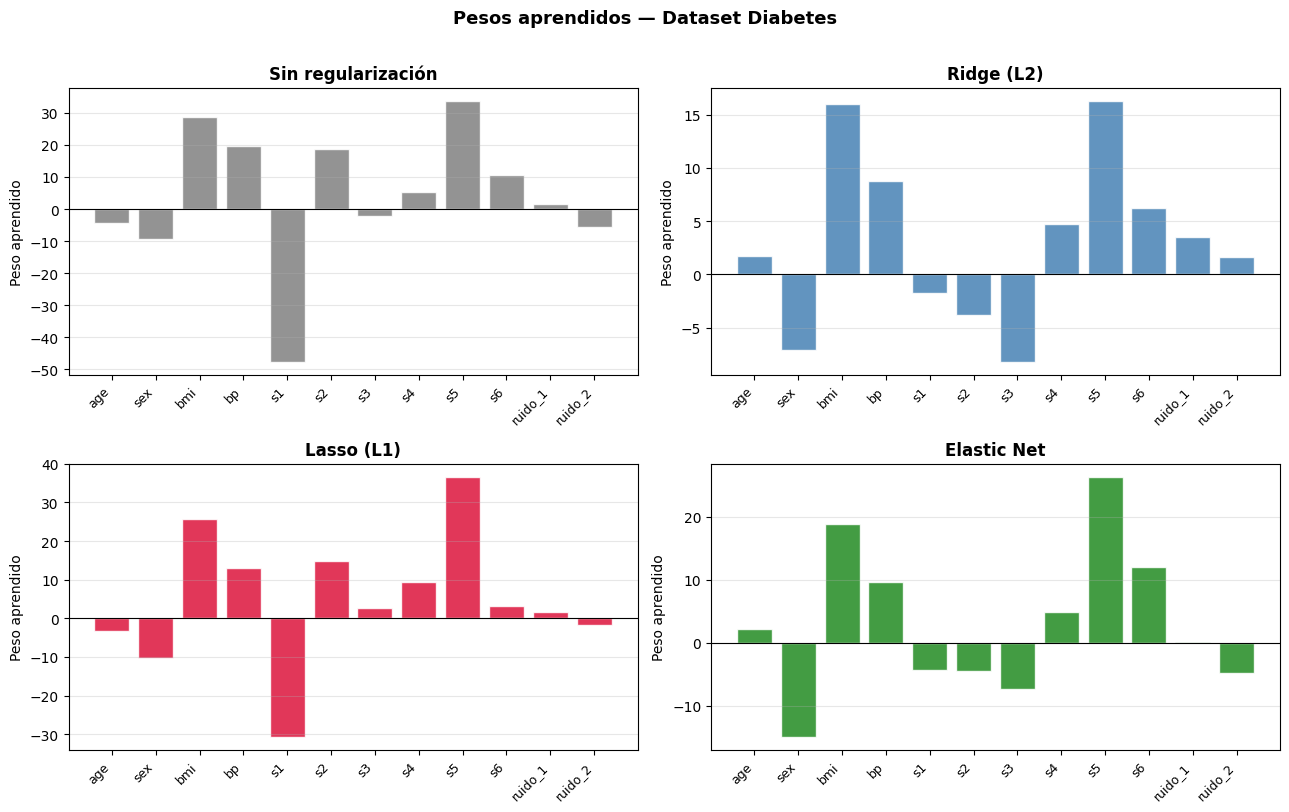

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
colors = ['gray', 'steelblue', 'crimson', 'forestgreen']
x_pos = np.arange(n_features)

for ax, (nombre, m), color in zip(axes, modelos.items(), colors):
    pesos = m.w[1:]    # saltamos el bias
    bars  = ax.bar(x_pos, pesos, color=color, alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=9)
    ax.set_title(nombre, fontweight='bold')
    ax.set_ylabel('Peso aprendido')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Pesos aprendidos — Dataset Diabetes', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Sparsity: ¿cuántos pesos se anulan?

Con datos reales, Lasso puede anular features que en realidad **sí tienen señal** (falsos negativos).
Por eso es crucial ajustar λ con cross-validation.

In [ ]:
threshold = 2 

print(f"{'Modelo':<22} {'Pesos ≈ 0':>10} {'Pesos activos':>14}")
print("-" * 48)
for nombre, m in modelos.items():
    pesos = m.w[1:]
    n_zero   = np.sum(np.abs(pesos) < threshold)
    n_active = n_features - n_zero
    print(f"{nombre:<22} {n_zero:>10} {n_active:>14}")

Modelo                  Pesos ≈ 0  Pesos activos
------------------------------------------------
Sin regularización              1             11
Ridge (L2)                      3              9
Lasso (L1)                      2             10
Elastic Net                     1             11


---
## Conclusiones

**Matemáticas**:
- Ridge añade $2\lambda w_j$ al gradiente → encoge los pesos proporcionalmente, nunca a 0
- Lasso añade $\lambda\,\text{sign}(w_j)$ → la función no-diferenciable en 0 crea un "imán" que fija pesos exactamente en 0
- Geométricamente: la esfera de L2 toca las curvas de nivel del MSE en puntos genéricos; el rombo de L1 lo hace en sus esquinas (donde los ejes marcan $w_j = 0$)

**Con datos reales (Diabetes)**:
- Todos los features tienen algo de señal → Ridge casi nunca pone pesos a 0 y es razonable
- Lasso selecciona automáticamente los features más fuertes (bmi, s5, bp)
- Elastic Net es preferible cuando hay features correlacionados (s1–s6 en este dataset)
- **Siempre** estandarizar antes de regularizar: si las features tienen escalas distintas, $\lambda$ no es justo entre ellas
- Usar cross-validation para escoger el $\lambda$ óptimo en la práctica